## Adding Features

In [20]:
import numpy as np
import pandas as pd
#from darts import TimeSeries
import matplotlib.pyplot as plt
#from tqdm import tqdm
#import time
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, max_error

In [2]:
data = pd.read_csv('data_cleaned.csv')
data['date']= pd.to_datetime(data['Unnamed: 0'])
#data.set_index('Unnamed: 0', inplace=True)

In [3]:
train = data[data['date']<'2014-01-01']
test = data[data['date']>='2014-01-01']

#train = TimeSeries.from_dataframe(train, value_cols='unit_sales')
#test = TimeSeries.from_dataframe(test, value_cols='unit_sales')

In [4]:
# Lag features (per store and item)
train['lag_1'] = train['unit_sales'].shift(1)
train['lag_7'] = train['unit_sales'].shift(7)
train['lag_30'] = train['unit_sales'].shift(30)

# Rolling statistics
train['rollings_avg_3'] = train["unit_sales"].rolling(window=3).mean().shift(1)

In [5]:
#hinzufügen: wochentag, is weekend, holidays, oil
train['day_of_week'] = train['date'].dt.dayofweek
train['is_weekend'] = train['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

#import holidays
holidays=pd.read_csv('holidays_cleaned.csv')
holidays['date']= pd.to_datetime(holidays['date'])
#holidays.drop('Unnamed: 0', axis=1, inplace=True)
#holidays.set_index('Unnamed: 0', inplace=True)

In [6]:
#if there's a holiday on that day/ that day in the list of holidays, the value is 1
train['is_holiday']=train['date'].apply(lambda x: 1 if x in set(holidays['date']) else 0)

In [7]:
oil=pd.read_csv('oil_cleaned.csv')
oil['date']= pd.to_datetime(oil['Unnamed: 0'])

In [8]:
oil.head()

,Unnamed: 0,dcoilwtico,date
0,2013-01-01,NaN,2013-01-01
1,2013-01-02,93.14,2013-01-02
2,2013-01-03,92.97,2013-01-03
3,2013-01-04,93.12,2013-01-04
4,2013-01-05,93.12,2013-01-05


In [9]:
oil.drop('Unnamed: 0', axis=1, inplace=True)
train=pd.merge(train,oil, on='date', how='left')
# join, to be sure, that the dates and Oil price is right.
# left: because train is the important one, I need all of it and nothing more.

In [10]:
train.drop('Unnamed: 0', axis=1, inplace=True) #dunno how that got there
#train.dropna() #no Nan values # xgboost is okay with nan values, so I don't have to

## XGBoost

In [11]:
# defining y and x
y_train = train['unit_sales']
x_train = train.drop('unit_sales', axis=1)
x_train= x_train.drop('date', axis=1)

y_test = test.drop('date', axis=1)

In [12]:
# Initialize the XGBoost regressor
model_xgboost = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)

# Train the XGBoost model
model_xgboost.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
train

,unit_sales,date,lag_1,lag_7,lag_30,rollings_avg_3,day_of_week,is_weekend,is_holiday,dcoilwtico
0,582.0,2013-01-02,NaN,NaN,NaN,NaN,2,0,0,93.14
1,310.0,2013-01-03,582.0,NaN,NaN,NaN,3,0,0,92.97
2,338.0,2013-01-04,310.0,NaN,NaN,NaN,4,0,0,93.12
3,654.0,2013-01-05,338.0,NaN,NaN,410.000000,5,1,1,93.12
4,979.0,2013-01-06,654.0,NaN,NaN,434.000000,6,1,0,93.12
...,...,...,...,...,...,...,...,...,...,...
359,419.0,2013-12-27,418.0,441.0,474.0,382.666667,4,0,0,99.94
360,499.0,2013-12-28,419.0,630.0,258.0,400.666667,5,1,0,99.94
361,552.0,2013-12-29,499.0,985.0,363.0,445.333333,6,1,0,99.94
362,595.0,2013-12-30,552.0,523.0,726.0,490.000000,0,0,0,98.90


In [14]:
#creating the columns for y iterative
'''
train_df = train.set_index("date")      #creating a new df to write into
history = train_df["unit_sales"].copy() #y values in history
forecasts = []                          #empty list for the forecast
last_date = history.index[-1]           #date of lag 1
next_date = last_date + pd.Timedelta(days=1)    #next date to forecast
'''

'\ntrain_df = train.set_index("date")      #creating a new df to write into\nhistory = train_df["unit_sales"].copy() #y values in history\nforecasts = []                          #empty list for the forecast\nlast_date = history.index[-1]           #date of lag 1\nnext_date = last_date + pd.Timedelta(days=1)    #next date to forecast\n'

In [35]:
def iterative_forecast(model, train_df, n_future_days):
    train_df = train_df.set_index("date")
    # Work on a copy so we don't mutate the original
    history = train_df["unit_sales"].copy()

    forecasts = []
    last_date = history.index[-1]

    for i in range(1, n_future_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        #
        # --- Lag features ---
        lag_1  = history.iloc[-1]
        lag_7  = history.iloc[-7]  if len(history) >= 7  else history.iloc[0]
        lag_30 = history.iloc[-30] if len(history) >= 30 else history.iloc[0]

        # --- Rolling average (last 2 values) ---
        rolling_avg_3 = history.iloc[-3:].mean()

        # --- Calendar features ---
        day_of_week = next_date.dayofweek          # 0 = Monday … 6 = Sunday
        is_weekend  = int(day_of_week >= 5)
        if next_date in set(holidays['date']):
            is_holiday= 1
        else:
            is_holiday = 0
        dcoilwtico  = oil[oil['date']==next_date]['dcoilwtico'].values[0]


        # --- Build the feature row (column order must match training) ---
        row = pd.DataFrame({
            "lag_1":          [lag_1],
            "lag_7":          [lag_7],
            "lag_30":         [lag_30],
            "rollings_avg_3": [rolling_avg_3],
            "day_of_week":    [day_of_week],
            "is_weekend":     [is_weekend],
            'is_holiday':     [is_holiday],
            "dcoilwtico":     [dcoilwtico]
        })

        #
        # --- Predict and store ---
        yhat = model.predict(row)[0]
        forecasts.append({"date": next_date, "unit_sales": yhat})

        # --- Append prediction to history so next iteration can use it ---
        history.loc[next_date] = yhat

    return pd.DataFrame(forecasts)

In [16]:
forecast_xgboost = iterative_forecast(model_xgboost, train, len(y_test))

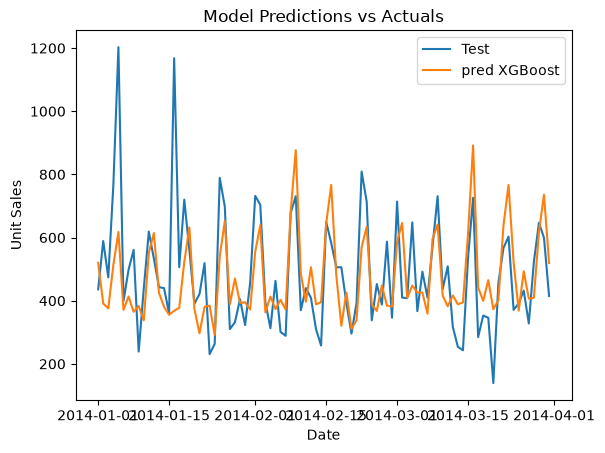

In [17]:
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(forecast_xgboost['date'], forecast_xgboost['unit_sales'], label='pred XGBoost')
plt.legend()
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.show()

In [22]:
model_evaluation=pd.DataFrame(columns=['model','mae','mse','r2', 'RSME', 'max_error'])

mae=mean_absolute_error(test['unit_sales'],forecast_xgboost['unit_sales'])
mse=mean_squared_error(test['unit_sales'],forecast_xgboost['unit_sales'])
r2= r2_score(test['unit_sales'],forecast_xgboost['unit_sales'])
rsme = np.sqrt(mse)
maxe = max_error(test['unit_sales'],forecast_xgboost['unit_sales'])

#new entry for the model at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['XGBoost', mae, mse, r2, rsme, maxe]

In [23]:
model_evaluation

,model,mae,mse,r2,RSME,max_error
0,XGBoost,111.520227,24328.601196,0.277325,155.976284,799.727509


## RandomForest

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
model_forest = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

model_forest.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [30]:
#lag 1, 7, 30, avg 3, weekday, weekend, holiday, oil
model_forest.feature_importances_

array([0.09918524, 0.07390737, 0.08969458, 0.05371077, 0.29495922,
       0.35122242, 0.00365246, 0.03366793])

#1weekend, 2weekday, lag 1, 30, 7, avg3, oil, holiday. with more information of the product, I could find better features

In [36]:
forecast_forest = iterative_forecast(model_forest, train, len(y_test))

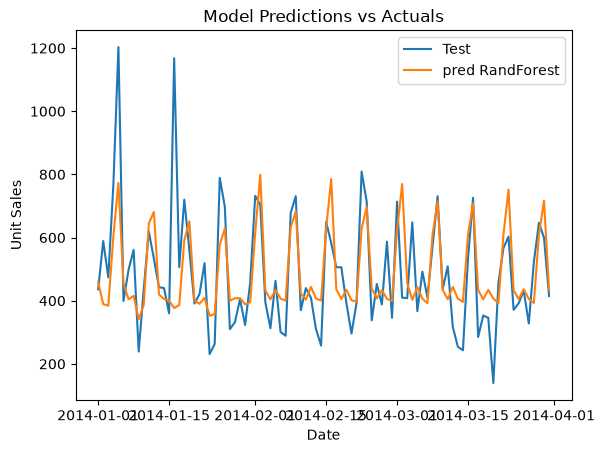

In [37]:
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(forecast_xgboost['date'], forecast_forest['unit_sales'], label='pred RandForest')
plt.legend()
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.show()

In [80]:
mae=mean_absolute_error(test['unit_sales'],forecast_forest['unit_sales'])
mse=mean_squared_error(test['unit_sales'],forecast_forest['unit_sales'])
r2= r2_score(test['unit_sales'],forecast_forest['unit_sales'])
rsme = np.sqrt(mse)
maxe = max_error(test['unit_sales'],forecast_forest['unit_sales'])

#new entry for the model at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['Random Forest', mae, mse, r2, rsme, maxe]

In [41]:
model_evaluation

,model,mae,mse,r2,RSME,max_error
0,XGBoost,111.520227,24328.601196,0.277325,155.976284,799.727509
2,Random Forest,97.723128,20260.468016,0.398168,142.339271,791.308597


## LinearRegression

In [42]:
from sklearn.linear_model import LinearRegression
#from sklearn.preprocessing import PolynomialFeatures

In [66]:
train_lr = train.dropna()                           #new df without Nan for the model
x_train_lr= train_lr.drop('unit_sales', axis=1)
y_train_lr= train_lr['unit_sales']

In [69]:
x_train_lr['date']=x_train_lr.index     #linear regression can't handle daytime objects

In [73]:
x_train_lr.drop('date',axis=1,inplace=True)

In [74]:
model_linearr = LinearRegression()
model_linearr.fit(x_train_lr, y_train_lr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.08, 0.06, 0.02,...,225.56, 14.34, 0.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['lag_1','lag_7','lag_30',...,'is_weekend','is_holiday','dcoilwtico']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,148.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [75]:
forecast_linearr = iterative_forecast(model_linearr, train, len(y_test))

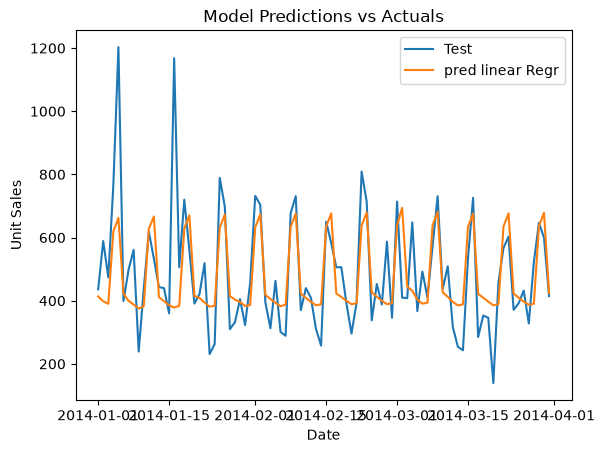

In [77]:
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(forecast_xgboost['date'], forecast_linearr['unit_sales'], label='pred linear Regr')
plt.legend()
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.show()

In [83]:
mae=mean_absolute_error(test['unit_sales'],forecast_linearr['unit_sales'])
mse=mean_squared_error(test['unit_sales'],forecast_linearr['unit_sales'])
r2= r2_score(test['unit_sales'],forecast_linearr['unit_sales'])
rsme = np.sqrt(mse)
maxe = max_error(test['unit_sales'],forecast_linearr['unit_sales'])

#new entry for the model at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['linear Regression', mae, mse, r2, rsme, maxe]

In [84]:
model_evaluation

,model,mae,mse,r2,RSME,max_error
0,XGBoost,111.520227,24328.601196,0.277325,155.976284,799.727509
2,linear Regression,91.392109,19372.014717,0.424559,139.183385,789.469338
3,linear Regression,91.392109,19372.014717,0.424559,139.183385,789.469338


even without scaling linear regression is the best one in all metrics